# End to End Deep Learning Project Using Simple RNN

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import datetime

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input, SimpleRNN, GRU, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from sklearn.model_selection import train_test_split
from keras import initializers


In [2]:
# Load the Imdb dataset

max_features= 10000 ## vocabulary size
(X_train,y_train),(X_test,y_test)= imdb.load_data(num_words=max_features)

print(f'Training data shape: {X_train.shape}, training labels shape: {y_train.shape}')
print(f'Testing data shape: {X_test.shape}, testing labels shape: {y_test.shape}')

Training data shape: (25000,), training labels shape: (25000,)
Testing data shape: (25000,), testing labels shape: (25000,)


In [3]:
X_train[0]


[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [4]:
y_train[0]


np.int64(1)

In [5]:
## Inspect a sample review and its label

sample_review= X_train[0]
sample_label= y_train[0]


In [6]:
# Map word index to words
word_to_index= imdb.get_word_index()

word_to_index



{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [7]:
reverse_word_index= {value: key for key, value in word_to_index.items()}

reverse_word_index



{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [8]:
decoded_review= ' '.join([reverse_word_index.get(i -3, '?') for i in sample_review])

decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

In [9]:
max_length= 500

X_train= sequence.pad_sequences(X_train, maxlen=max_length)
X_test= sequence.pad_sequences(X_test, maxlen=max_length)

X_train[0]



array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

The IMDB dataset provided by Keras contains movie reviews that have already been preprocessed into Bag-of-Words format, where each word is represented by an integer index based on a predefined vocabulary size of 10,000. Along with the dataset, a dictionary mapping of words to their corresponding indices is provided, which makes it possible to decode the reviews back into their textual form.

Before the data can be used as input for a neural network, the sequence lengths must be standardized. This is accomplished using the pad_sequences method, where the maximum sequence length is set to 500. As a result, all reviews are either truncated or padded to ensure uniform shape, making them suitable for processing in the model pipeline.

# Train Simple RNN

## Test

In [10]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [11]:
initializer_1 = initializers.HeUniform(seed=42) # "glorot_Uniform"
initializer_2 = initializers.GlorotUniform(seed=42)
initializer_3 = initializers.LecunUniform(seed=42)

In [12]:
model= Sequential()
model.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
model.add(SimpleRNN(128, return_sequences=True,activation="tanh", kernel_initializer="glorot_uniform"))
model.add(SimpleRNN(128, return_sequences=False,activation="tanh", kernel_initializer="glorot_uniform"))
model.add(Dense(1, activation='sigmoid'))


c:\Users\Rondon\Documents\1. Python Starter\16.krish_IA_Udemy\04.02.deep_learning_4_nlp\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
c:\Users\Rondon\Documents\1. Python Starter\16.krish_IA_Udemy\04.02.deep_learning_4_nlp\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 500, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345,921 (5.13 MB)

 Trainable params: 1,345,921 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
## Set Early Stopping

early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [15]:
## Set up the TensorBoard callback
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [16]:
Optimizer= Adam(learning_rate=0.001)

model.compile(loss='binary_crossentropy', optimizer=Optimizer, metrics=['accuracy'])



In [17]:

history= model.fit(X_train, y_train, epochs=500, batch_size=256, validation_split=0.2, callbacks=[early_stopping, tensorboard_callback], verbose=1)



Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 49s 602ms/step - accuracy: 0.5300 - loss: 0.7025 - val_accuracy: 0.5730 - val_loss: 0.6576
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 50s 632ms/step - accuracy: 0.7103 - loss: 0.5592 - val_accuracy: 0.8240 - val_loss: 0.4018
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 49s 627ms/step - accuracy: 0.8716 - loss: 0.3146 - val_accuracy: 0.8380 - val_loss: 0.3776
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 51s 640ms/step - accuracy: 0.9271 - loss: 0.1931 - val_accuracy: 0.8372 - val_loss: 0.4222
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 45s 566ms/step - accuracy: 0.9481 - loss: 0.1389 - val_accuracy: 0.8232 - val_loss: 0.5134
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 46s 578ms/step - accuracy: 0.9767 - loss: 0.0712 - val_accuracy: 0.7936 - val_loss: 0.6265
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 44s 560ms/step - accuracy: 0.9862 - loss: 0.0449 - val_accuracy: 0.7764 - val_loss: 0.7693
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 44s 564ms/step - accuracy: 0.9852 - loss: 0.0425 - 

In [18]:
## Load tensorboard
%load_ext tensorboard
%tensorboard --logdir=logs\fit\20250421-161321

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Failed to canonicalize script path

In [19]:
model.evaluate(X_test, y_test)


782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.8389 - loss: 0.3798


[0.3783753216266632, 0.8410800099372864]

In [20]:
#model.save('pickle/simple_rnn_best_model.h5')


# RNN

initializer_1 = initializers.HeNormal(seed=42) 

initializer_2 = initializers.GlorotNormal(seed=42)

initializer_3 = initializers.LecunNormal(seed=42)

## HE 

In [21]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [22]:
RNN_HE= Sequential()
RNN_HE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
RNN_HE.add(SimpleRNN(128, return_sequences=True,activation="relu", kernel_initializer=initializer_1))
RNN_HE.add(SimpleRNN(128, return_sequences=False,activation="relu", kernel_initializer=initializer_1))
RNN_HE.add(Dense(1, activation='sigmoid'))

RNN_HE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 500, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345,921 (5.13 MB)

 Trainable params: 1,345,921 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [24]:
Optimizer= Adam(learning_rate=0.001)

RNN_HE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [25]:

history_RNN_HE= RNN_HE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)


Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 34s 414ms/step - accuracy: 0.5743 - loss: 0.6591 - val_accuracy: 0.7646 - val_loss: 0.4858
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 32s 408ms/step - accuracy: 0.7447 - loss: 0.5414 - val_accuracy: 0.6514 - val_loss: 0.5983
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 35s 444ms/step - accuracy: 0.7167 - loss: 0.5239 - val_accuracy: 0.7410 - val_loss: 0.4959
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 34s 428ms/step - accuracy: 0.8354 - loss: 0.3825 - val_accuracy: 0.7982 - val_loss: 0.4599
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 33s 422ms/step - accuracy: 0.8823 - loss: 0.2814 - val_accuracy: 0.7704 - val_loss: 0.5010
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 34s 428ms/step - accuracy: 0.8683 - loss: 0.3239 - val_accuracy: 0.7848 - val_loss: 0.4692
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 34s 431ms/step - accuracy: 0.8769 - loss: 0.2978 - val_accuracy: 0.8182 - val_loss: 0.5063
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 37s 471ms/step - accuracy: 0.9286 - loss: 0.1901 - 

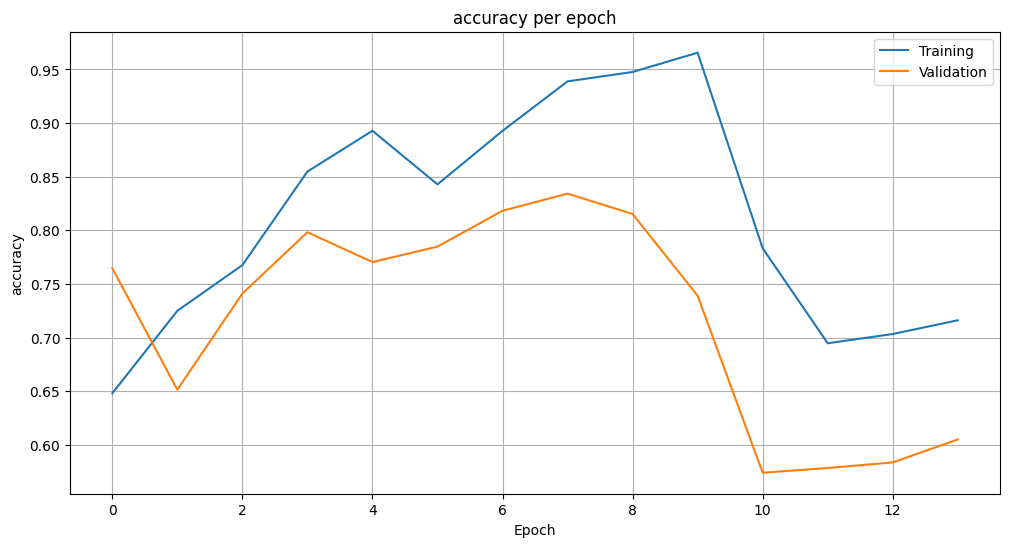

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(history_RNN_HE.history['accuracy'])
plt.plot(history_RNN_HE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [27]:
RNN_HE.evaluate(X_test, y_test)


782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.7989 - loss: 0.4651


[0.4581412971019745, 0.8007599711418152]

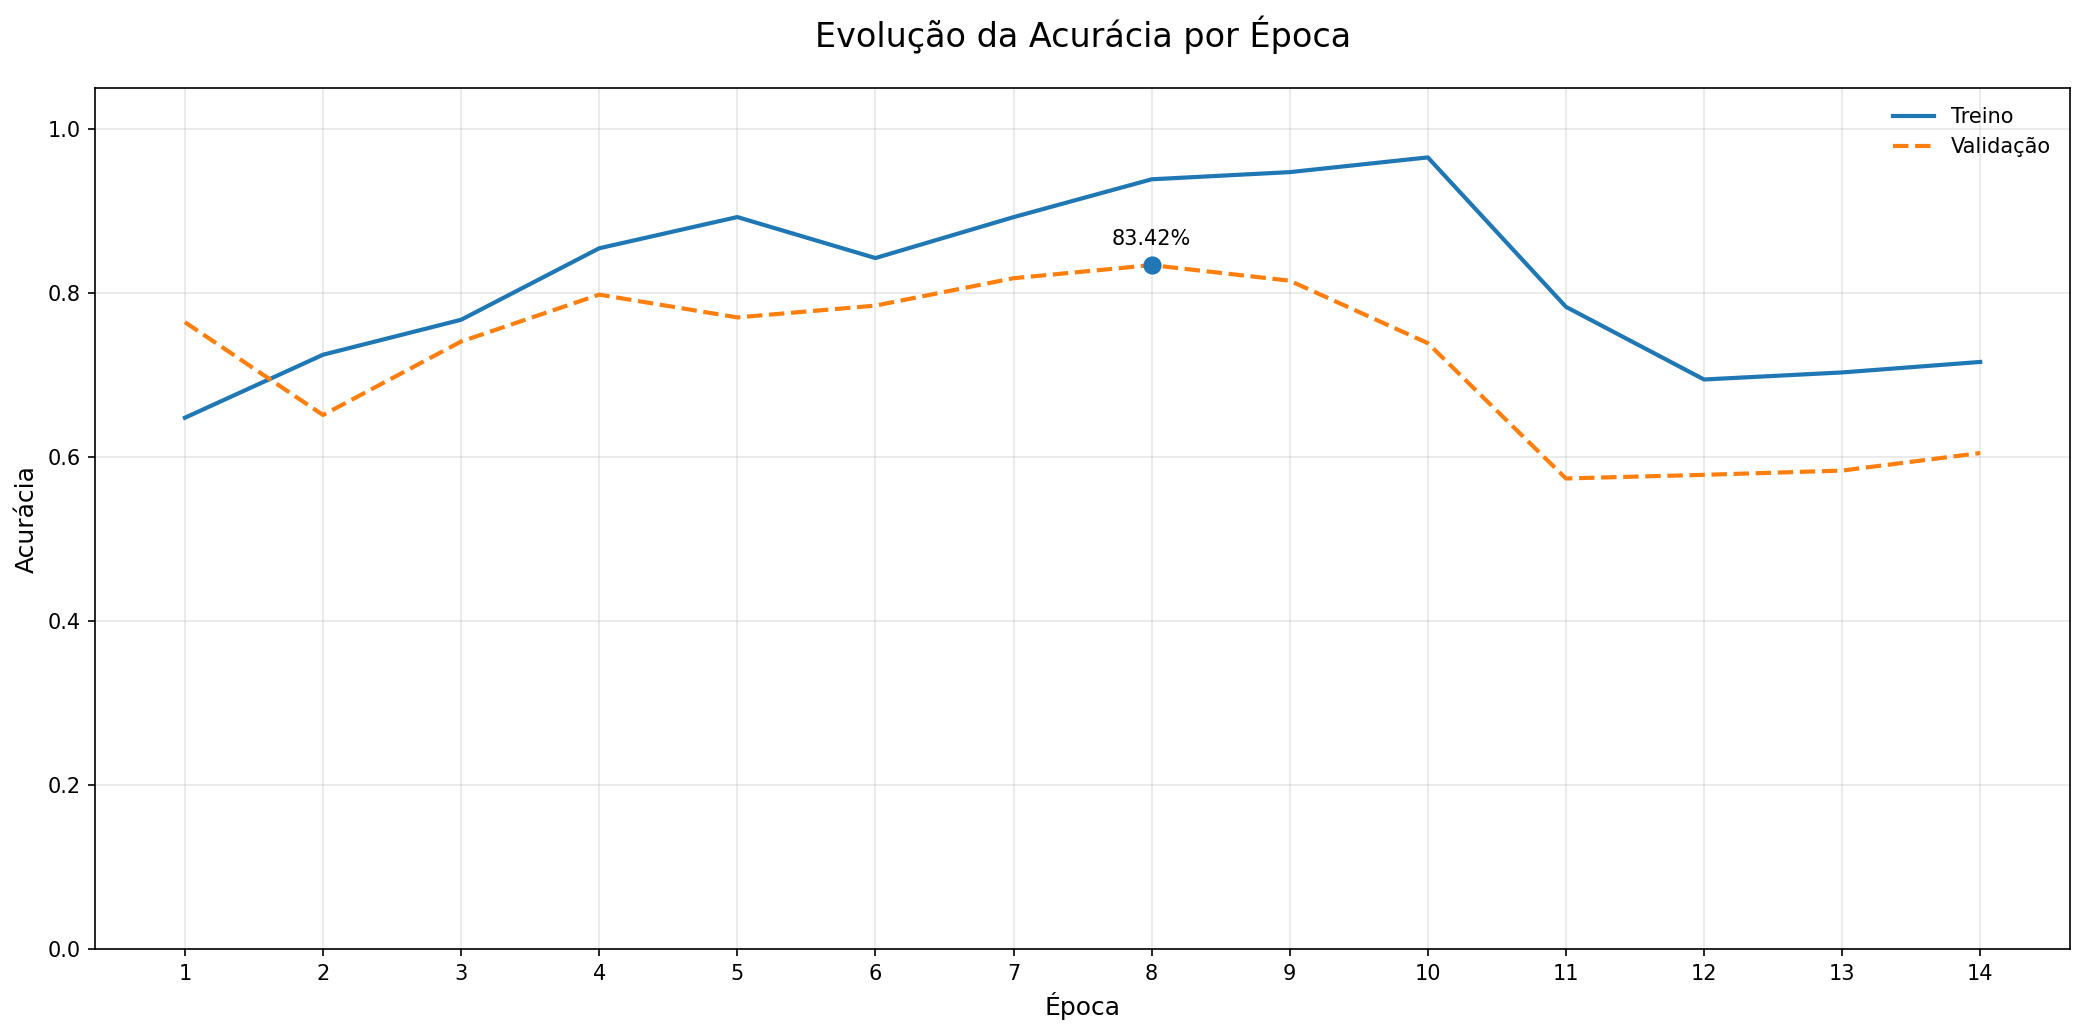

In [28]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_RNN_HE.history['accuracy']
val_acc   = history_RNN_HE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()

## GLorot

In [29]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [30]:
RNN_GL= Sequential()
RNN_GL.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
RNN_GL.add(SimpleRNN(128, return_sequences=True,activation="tanh", kernel_initializer=initializer_2))
RNN_GL.add(SimpleRNN(128, return_sequences=False,activation="tanh", kernel_initializer=initializer_2))
RNN_GL.add(Dense(1, activation='sigmoid'))

RNN_GL.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 500, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345,921 (5.13 MB)

 Trainable params: 1,345,921 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [32]:
Optimizer= Adam(learning_rate=0.001)

RNN_GL.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [33]:
history_RNN_GL= RNN_GL.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 43s 517ms/step - accuracy: 0.5032 - loss: 0.7134 - val_accuracy: 0.5234 - val_loss: 0.6892
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 505ms/step - accuracy: 0.5419 - loss: 0.6882 - val_accuracy: 0.5632 - val_loss: 0.6748
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 512ms/step - accuracy: 0.6241 - loss: 0.6430 - val_accuracy: 0.5954 - val_loss: 0.6494
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 510ms/step - accuracy: 0.7176 - loss: 0.5480 - val_accuracy: 0.6428 - val_loss: 0.6611
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 500ms/step - accuracy: 0.8056 - loss: 0.4204 - val_accuracy: 0.6308 - val_loss: 0.7888
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 497ms/step - accuracy: 0.8547 - loss: 0.3318 - val_accuracy: 0.6418 - val_loss: 0.9560
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 495ms/step - accuracy: 0.8999 - loss: 0.2471 - val_accuracy: 0.6698 - val_loss: 0.9163
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 512ms/step - accuracy: 0.9295 - loss: 0.1878 - 

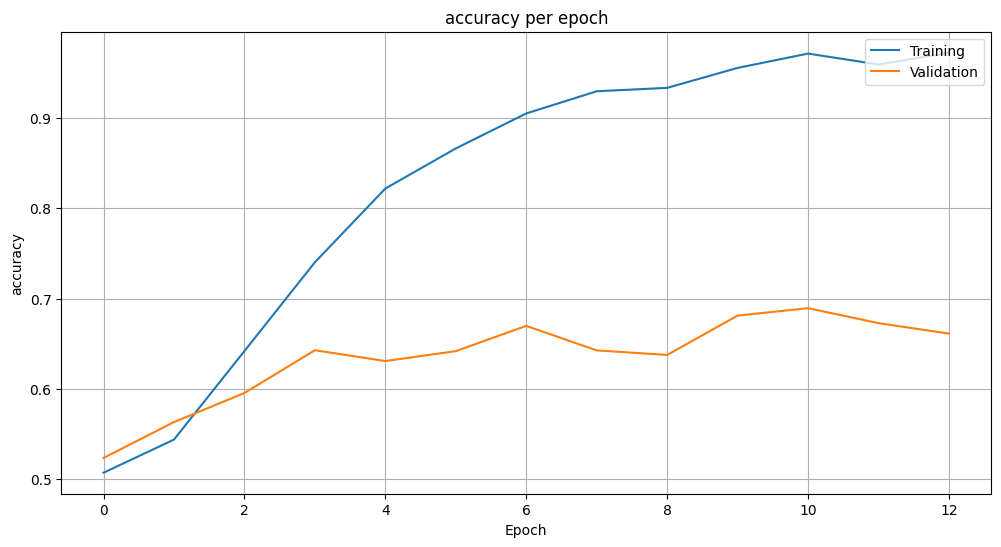

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(history_RNN_GL.history['accuracy'])
plt.plot(history_RNN_GL.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [35]:
RNN_GL.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.5980 - loss: 0.6498


[0.6492294669151306, 0.5975199937820435]

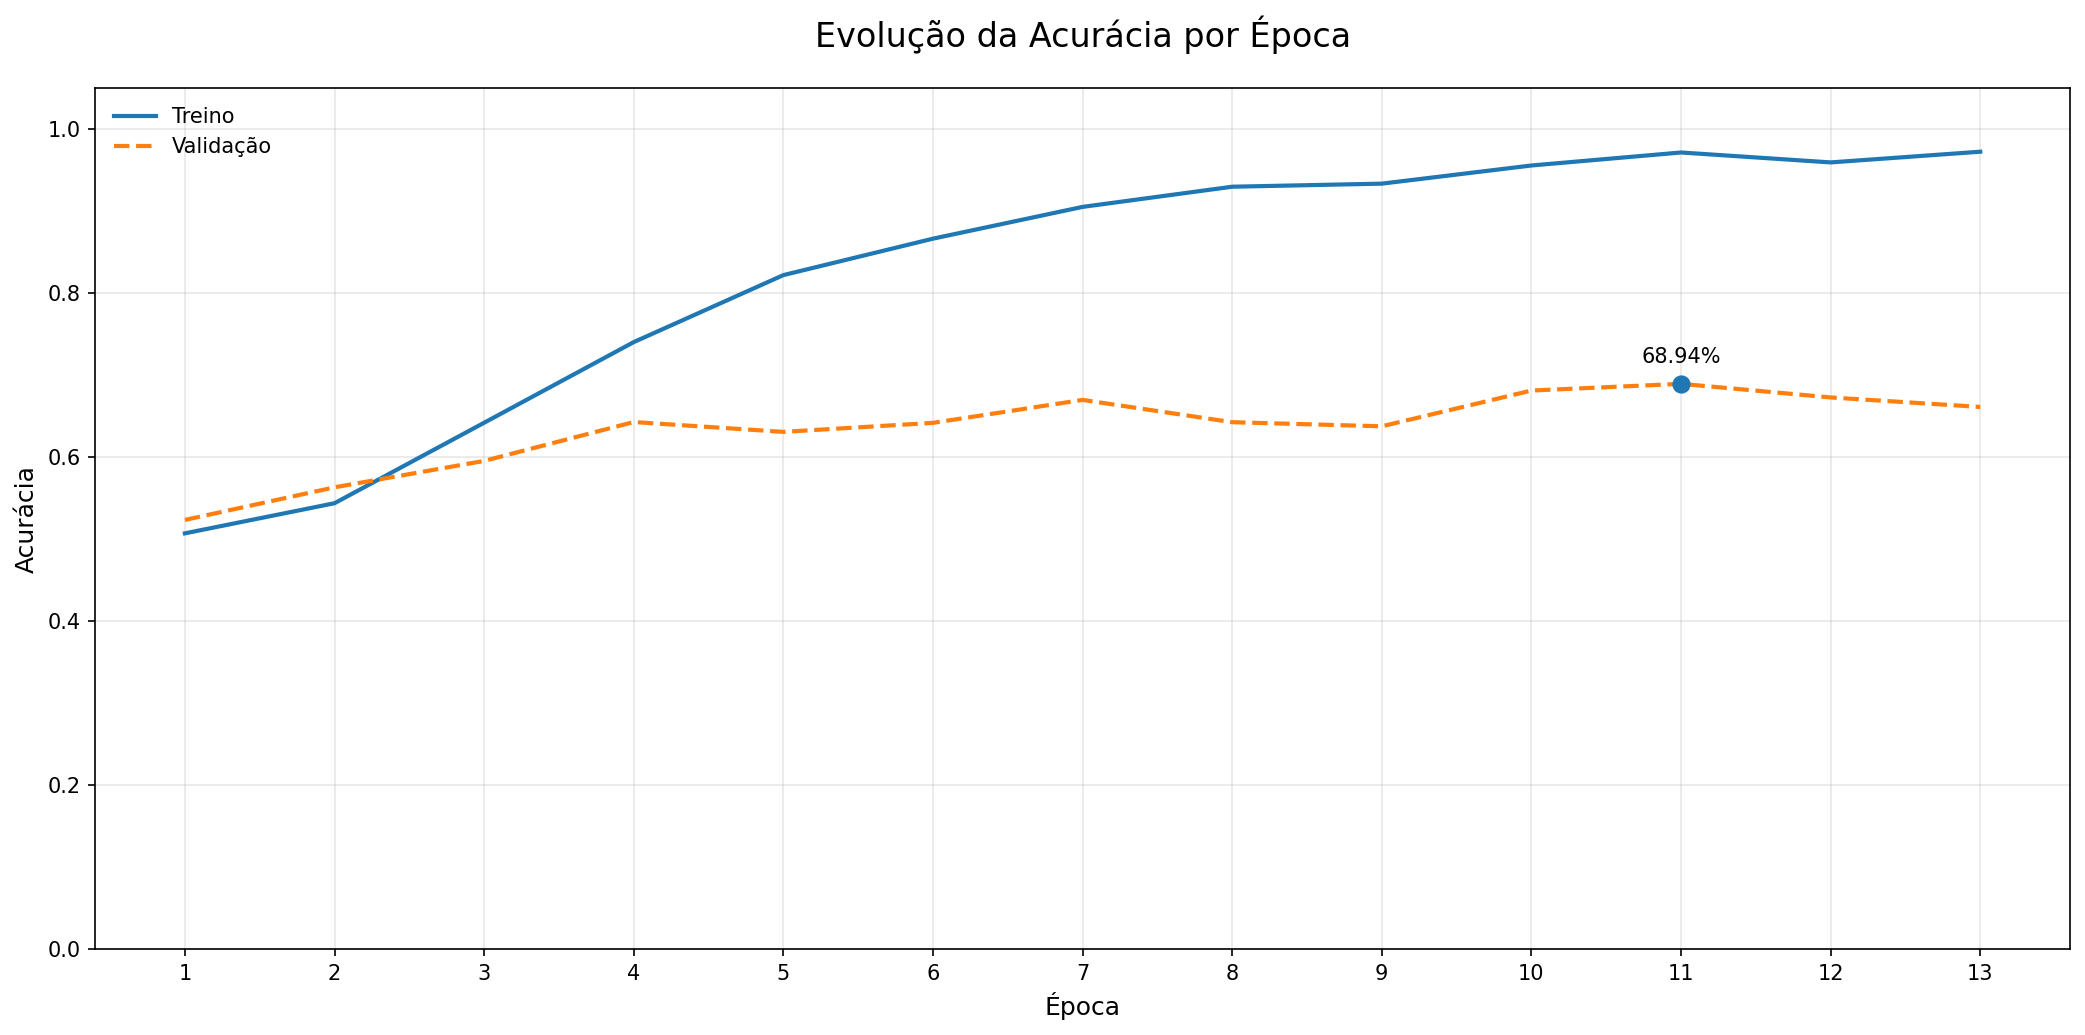

In [36]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_RNN_GL.history['accuracy']
val_acc   = history_RNN_GL.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


## LeCun

In [37]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [38]:
RNN_LE= Sequential()
RNN_LE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
RNN_LE.add(SimpleRNN(128, return_sequences=True,activation="tanh", kernel_initializer=initializer_3))
RNN_LE.add(SimpleRNN(128, return_sequences=False,activation="tanh", kernel_initializer=initializer_3))
RNN_LE.add(Dense(1, activation='sigmoid'))

RNN_LE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 500, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345,921 (5.13 MB)

 Trainable params: 1,345,921 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

RNN_LE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [40]:
history_RNN_LE= RNN_LE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 490ms/step - accuracy: 0.5313 - loss: 0.6940 - val_accuracy: 0.6520 - val_loss: 0.6143
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 37s 474ms/step - accuracy: 0.7288 - loss: 0.5508 - val_accuracy: 0.6614 - val_loss: 0.6109
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 492ms/step - accuracy: 0.8479 - loss: 0.3458 - val_accuracy: 0.6684 - val_loss: 0.7231
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 493ms/step - accuracy: 0.9526 - loss: 0.1288 - val_accuracy: 0.6082 - val_loss: 1.2759
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 485ms/step - accuracy: 0.8429 - loss: 0.3239 - val_accuracy: 0.5802 - val_loss: 0.6749
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 495ms/step - accuracy: 0.7167 - loss: 0.6157 - val_accuracy: 0.6576 - val_loss: 0.6100
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 493ms/step - accuracy: 0.7718 - loss: 0.4708 - val_accuracy: 0.6518 - val_loss: 0.6055
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 486ms/step - accuracy: 0.7986 - loss: 0.4318 - 

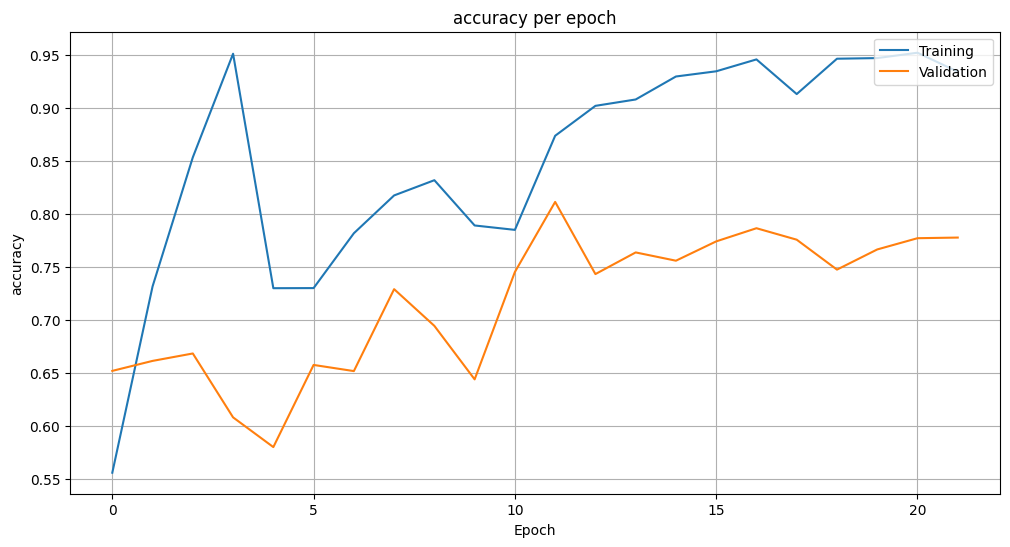

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(history_RNN_LE.history['accuracy'])
plt.plot(history_RNN_LE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [42]:
RNN_LE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.8060 - loss: 0.4791


[0.4718922972679138, 0.8095600008964539]

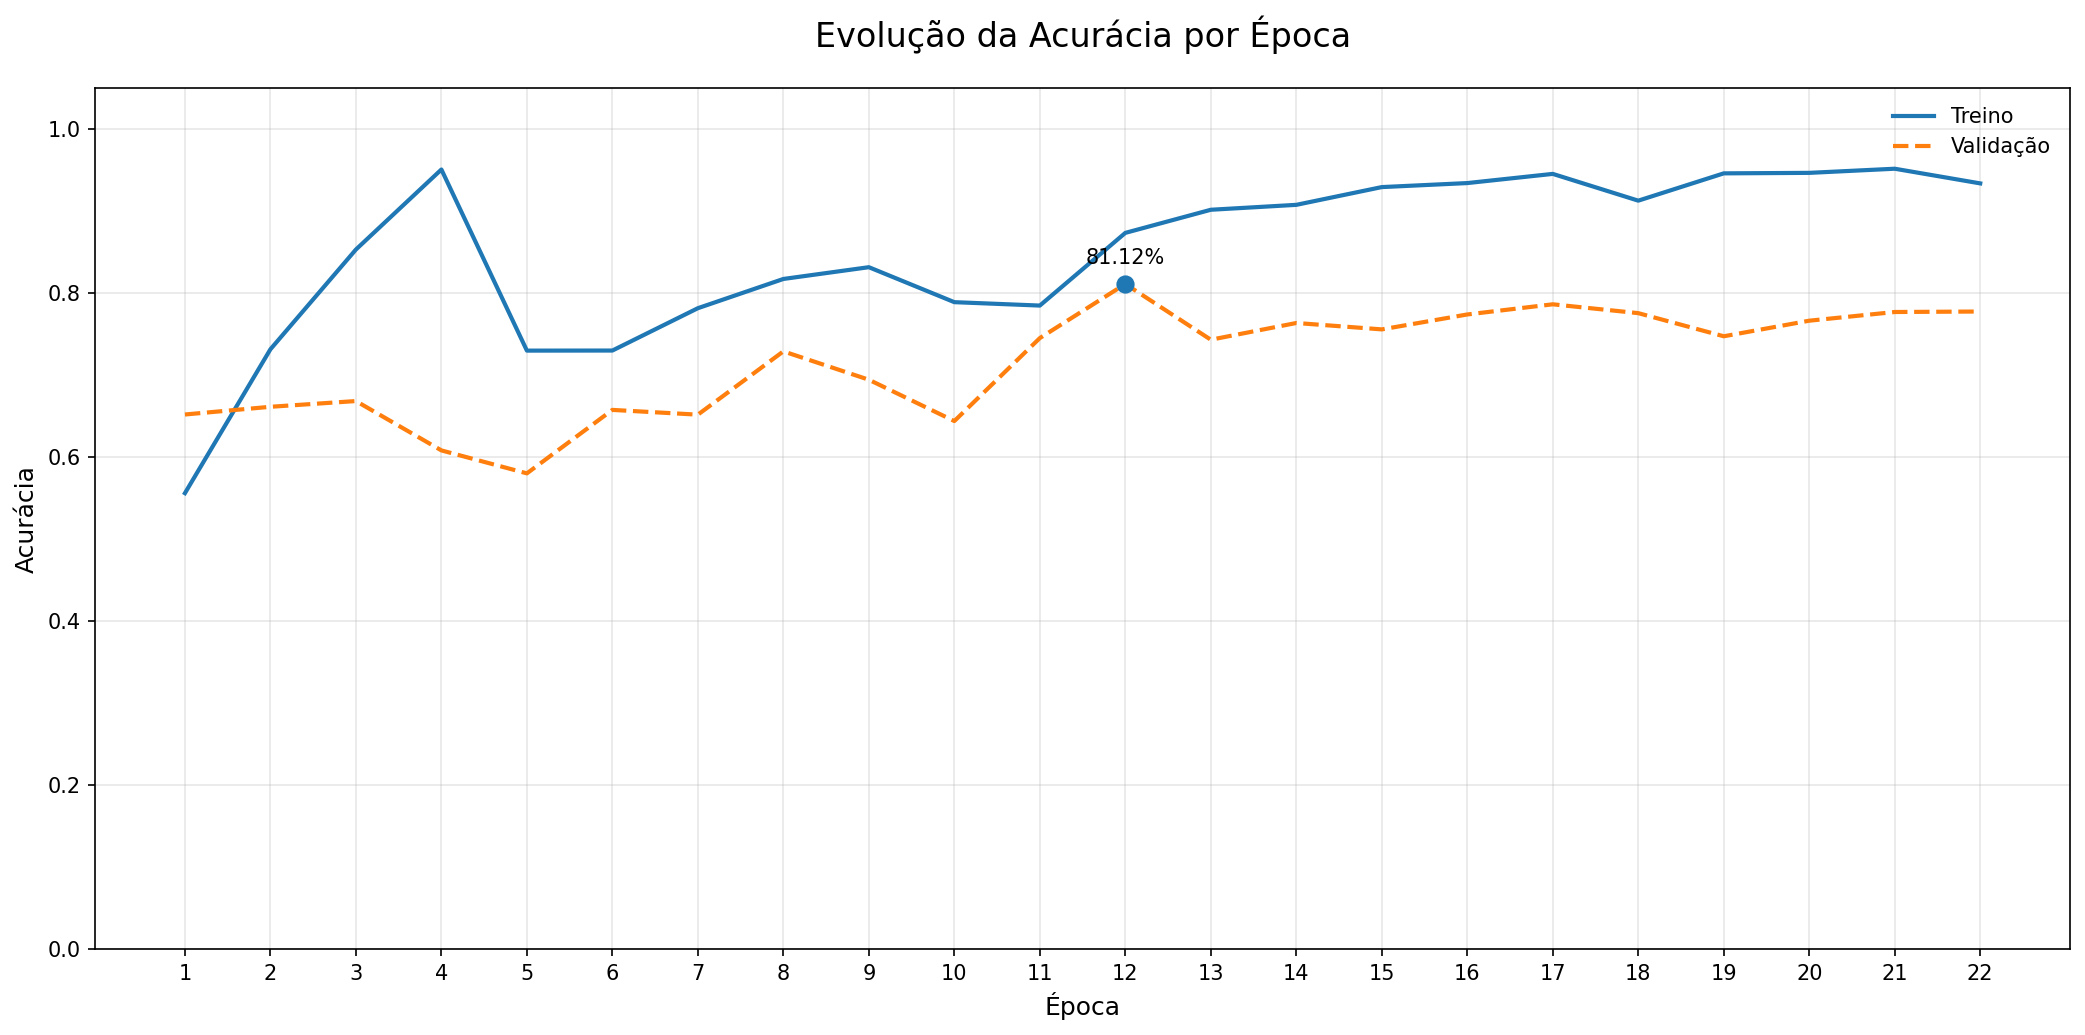

In [43]:


# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_RNN_LE.history['accuracy']
val_acc   = history_RNN_LE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


# LSTM

## HE 

In [44]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [45]:
LSTM_HE= Sequential()
LSTM_HE.add(Embedding(max_features, 50, input_length=max_length, input_shape=X_train.shape[1:]))
LSTM_HE.add(LSTM(64, return_sequences=True,activation="relu", kernel_initializer=initializer_1))
LSTM_HE.add(Dropout(0.2))
LSTM_HE.add(LSTM(32, return_sequences=True,activation="relu", kernel_initializer=initializer_1))
LSTM_HE.add(Dropout(0.2))
LSTM_HE.add(LSTM(32, return_sequences=False,activation="relu", kernel_initializer=initializer_1))
LSTM_HE.add(Dense(1, activation='sigmoid', kernel_initializer=initializer_2))

LSTM_HE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 50)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 500, 64)        │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 500, 32)        │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,209 (2.10 MB)

 Trainable params: 550,209 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

Optimizer= Adam(learning_rate=0.001)

LSTM_HE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [47]:
history_LSTM_HE= LSTM_HE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.5345 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 9/500
79/79 ━━━━━━

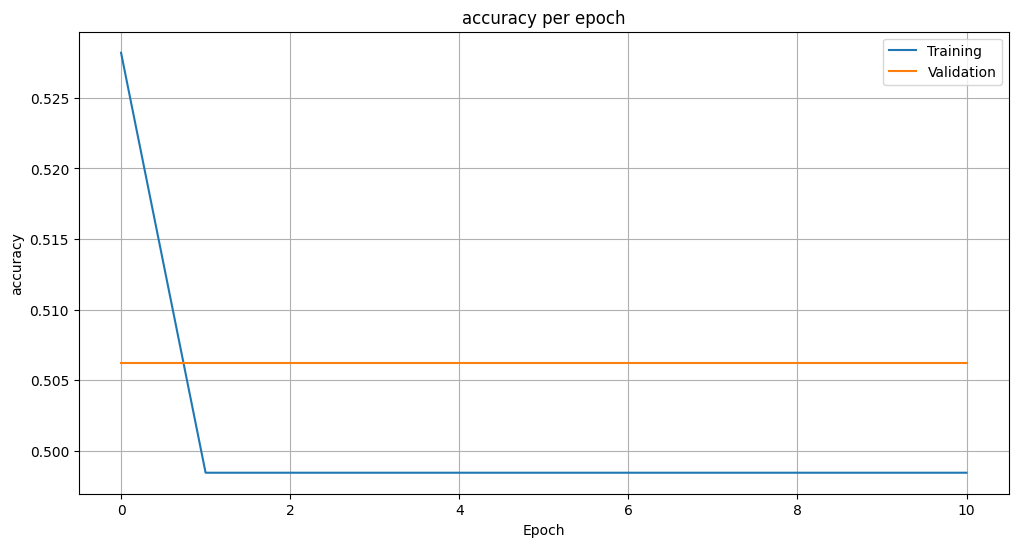

In [48]:
plt.figure(figsize=(12, 6))
plt.plot(history_LSTM_HE.history['accuracy'])
plt.plot(history_LSTM_HE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [49]:
LSTM_HE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 88s 113ms/step - accuracy: 0.5073 - loss: nan


[nan, 0.5]

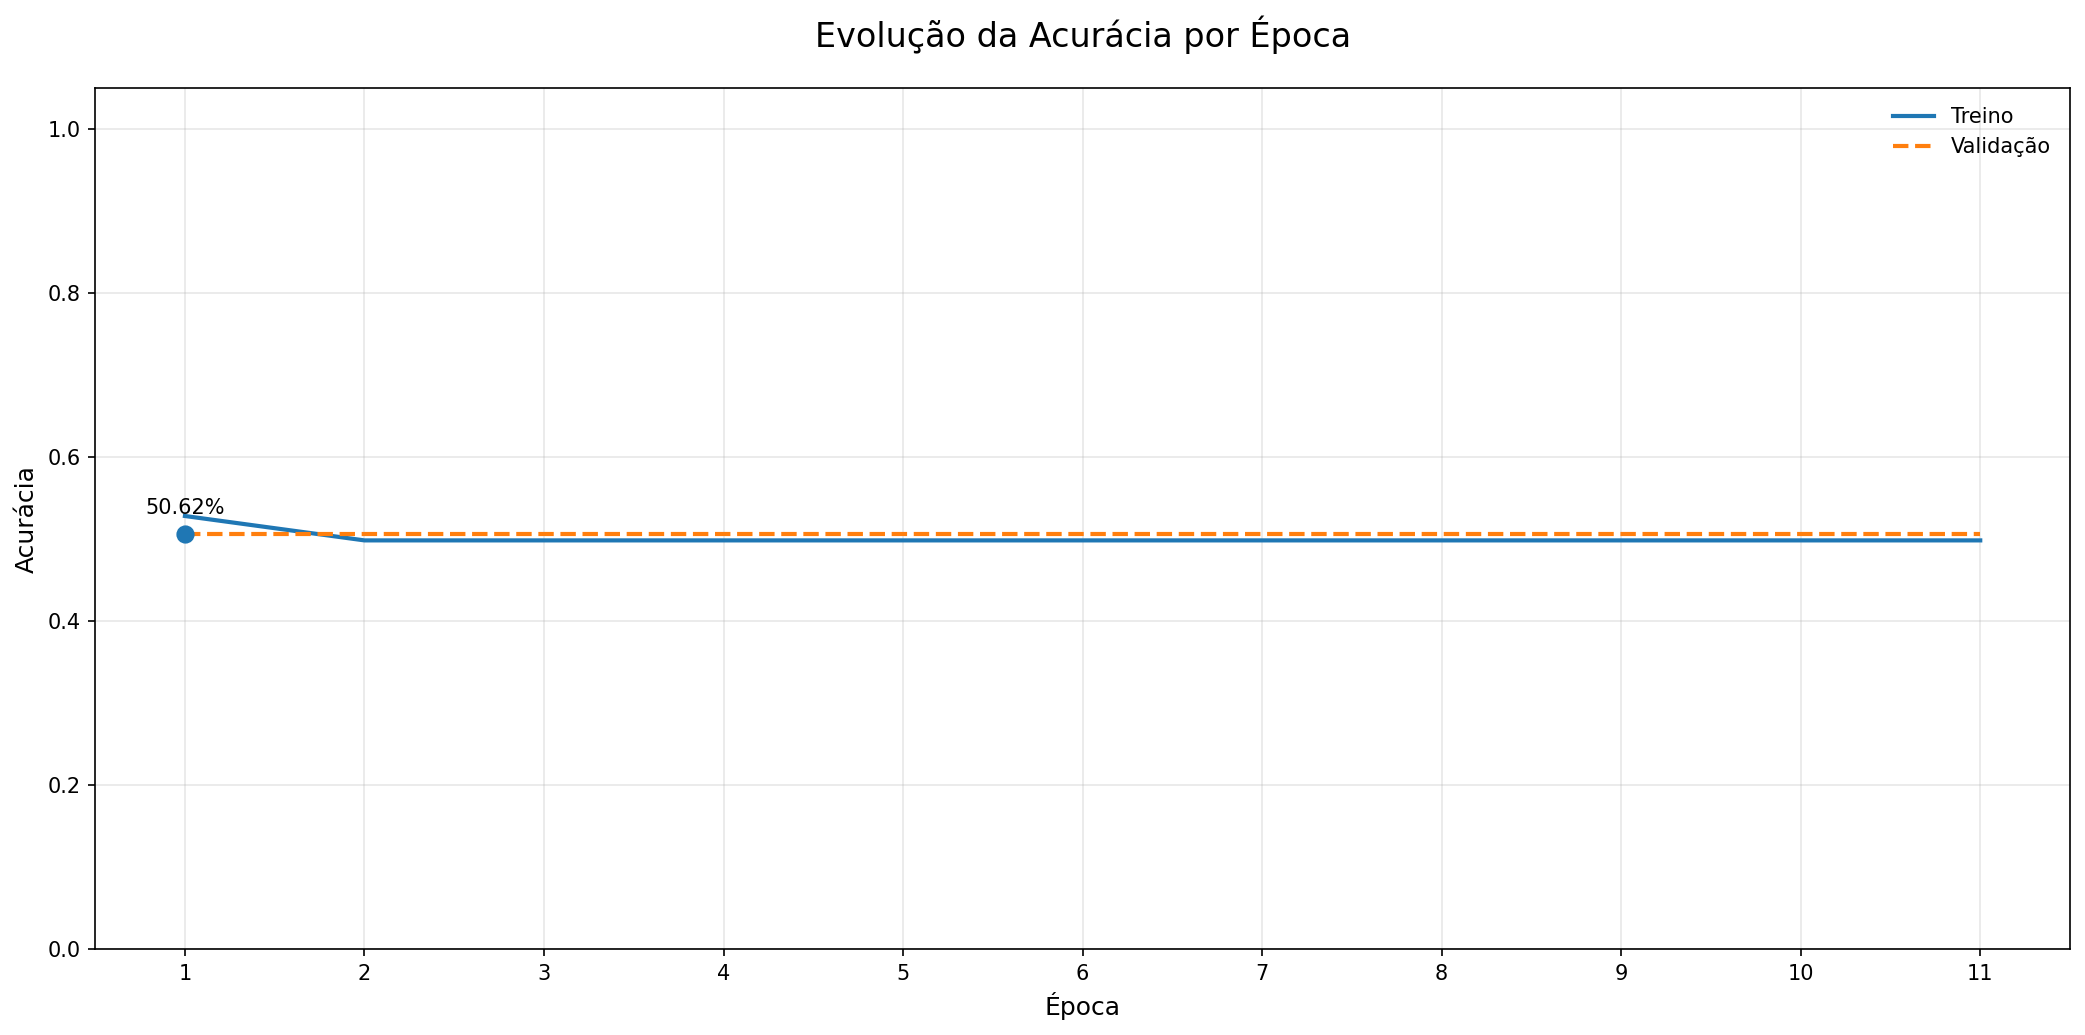

In [50]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_LSTM_HE.history['accuracy']
val_acc   = history_LSTM_HE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


## GLorot

In [51]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [52]:
LSTM_GL= Sequential()
LSTM_GL.add(Embedding(max_features, 50, input_length=max_length, input_shape=X_train.shape[1:]))
LSTM_GL.add(LSTM(64, return_sequences=True,activation="tanh", kernel_initializer=initializer_2))
LSTM_GL.add(Dropout(0.2))
LSTM_GL.add(LSTM(32, return_sequences=True,activation="tanh", kernel_initializer=initializer_2))
LSTM_GL.add(Dropout(0.2))
LSTM_GL.add(LSTM(32, return_sequences=False,activation="tanh", kernel_initializer=initializer_2))
LSTM_GL.add(Dense(1, activation='sigmoid', kernel_initializer=initializer_2))

LSTM_GL.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 50)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 500, 64)        │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 500, 32)        │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,209 (2.10 MB)

 Trainable params: 550,209 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

LSTM_GL.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [54]:
history_LSTM_GL= LSTM_GL.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.6103 - loss: 0.6258 - val_accuracy: 0.8484 - val_loss: 0.3633
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.8679 - loss: 0.3245 - val_accuracy: 0.8472 - val_loss: 0.3447
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.9033 - loss: 0.2501 - val_accuracy: 0.8718 - val_loss: 0.3084
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.9276 - loss: 0.2000 - val_accuracy: 0.8736 - val_loss: 0.3561
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.9284 - loss: 0.1972 - val_accuracy: 0.8388 - val_loss: 0.3777
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.9206 - loss: 0.2070 - val_accuracy: 0.8404 - val_loss: 0.3817
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.9418 - loss: 0.1674 - val_accuracy: 0.7994 - val_loss: 0.4284
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.8967 - loss: 0.2513 - val_accuracy: 0.

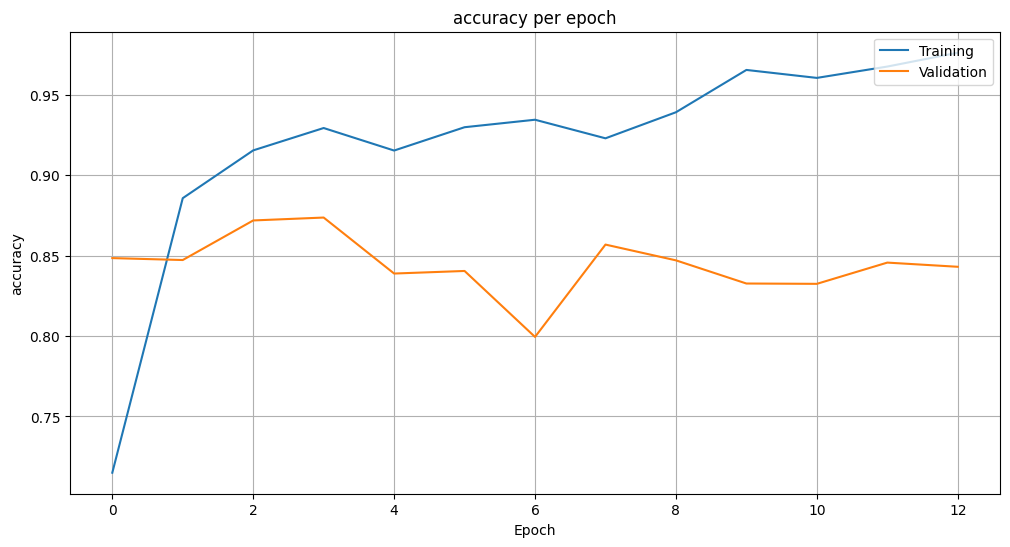

In [55]:
plt.figure(figsize=(12, 6))
plt.plot(history_LSTM_GL.history['accuracy'])
plt.plot(history_LSTM_GL.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [56]:
LSTM_GL.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 102s 130ms/step - accuracy: 0.8599 - loss: 0.3251


[0.32560423016548157, 0.8599200248718262]

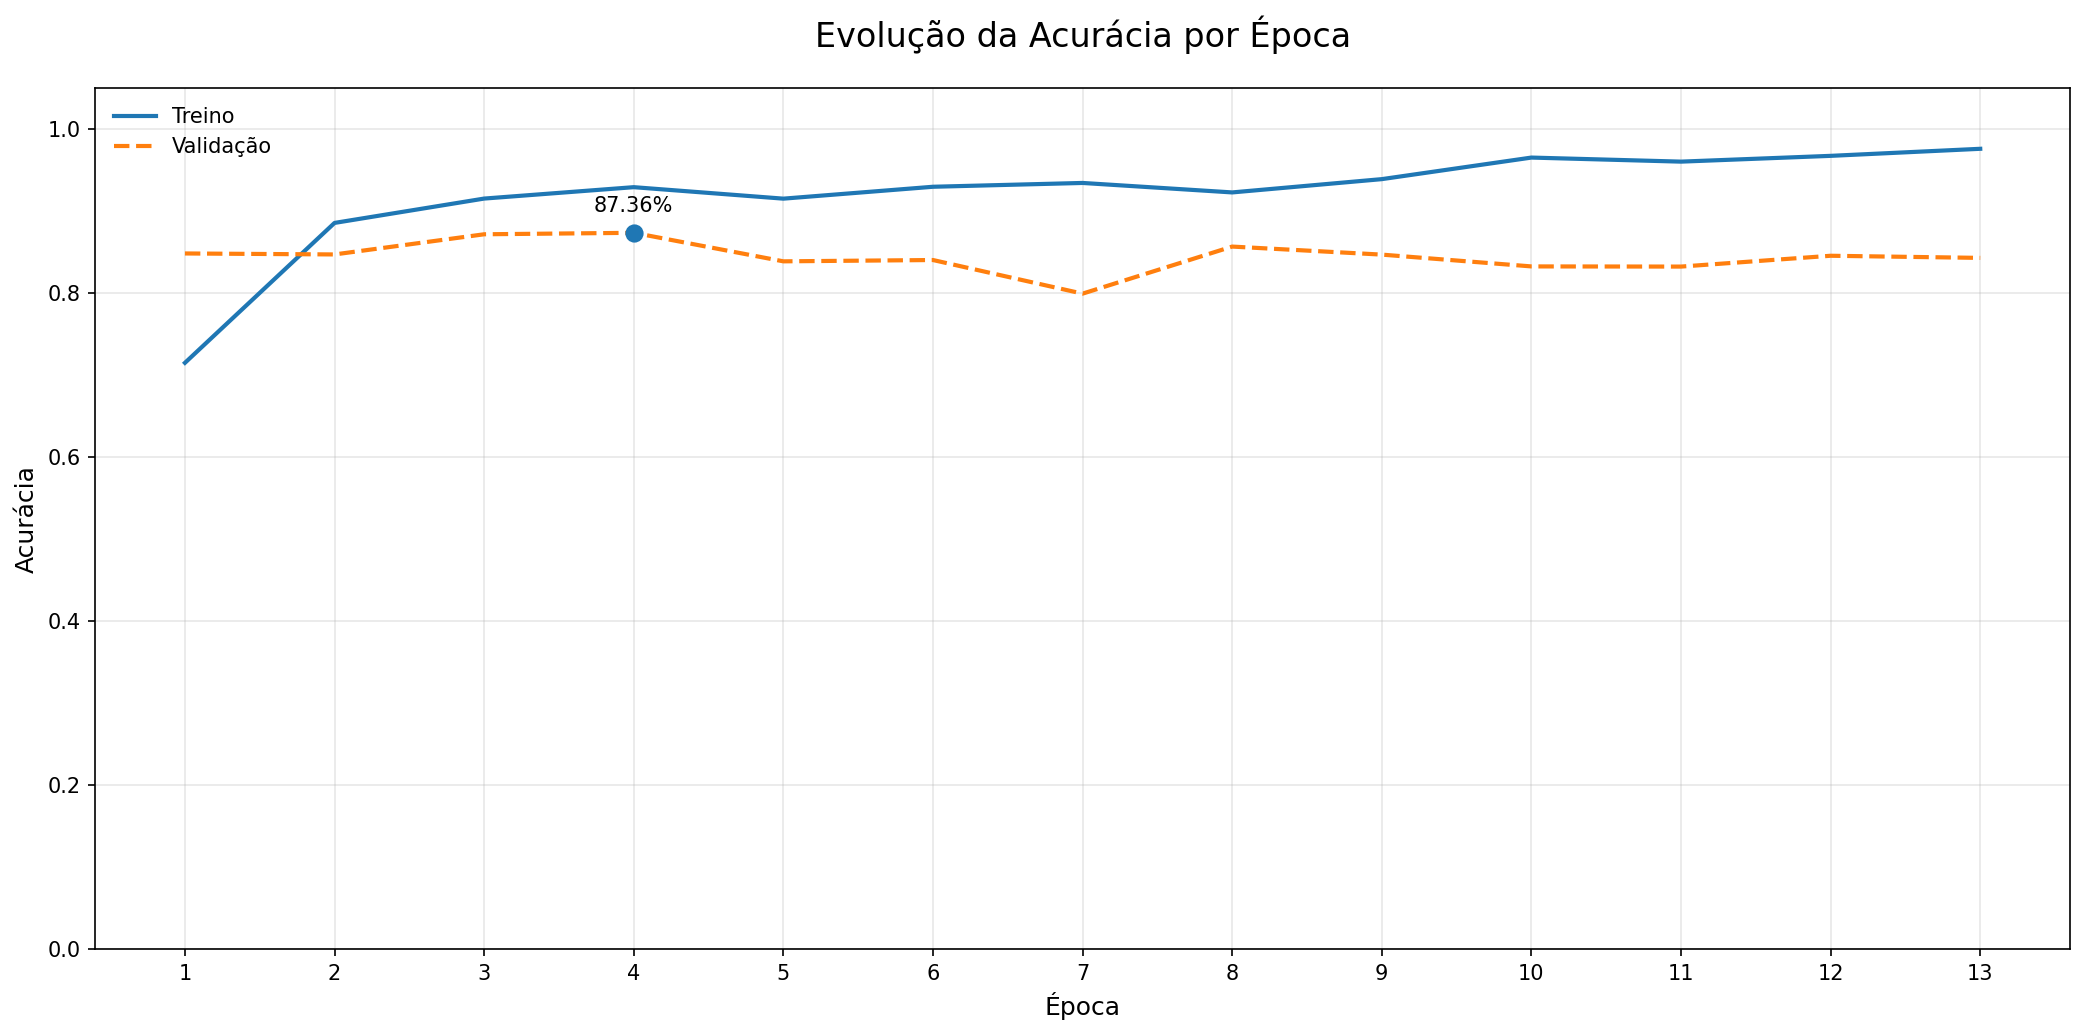

In [57]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_LSTM_GL.history['accuracy']
val_acc   = history_LSTM_GL.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()





## LeCun

In [58]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [59]:
LSTM_LE= Sequential()
LSTM_LE.add(Embedding(max_features, 50, input_length=max_length, input_shape=X_train.shape[1:]))
LSTM_LE.add(LSTM(64, return_sequences=True,activation="tanh", kernel_initializer=initializer_3))
LSTM_LE.add(Dropout(0.2))
LSTM_LE.add(LSTM(32, return_sequences=True,activation="tanh", kernel_initializer=initializer_3))
LSTM_LE.add(Dropout(0.2))
LSTM_LE.add(LSTM(32, return_sequences=False,activation="tanh", kernel_initializer=initializer_3))
LSTM_LE.add(Dense(1, activation='sigmoid', kernel_initializer=initializer_3))

LSTM_LE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 50)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 500, 64)        │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 500, 32)        │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,209 (2.10 MB)

 Trainable params: 550,209 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

LSTM_LE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [61]:
history_LSTM_LE= LSTM_LE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.6339 - loss: 0.6131 - val_accuracy: 0.8476 - val_loss: 0.3667
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.8861 - loss: 0.2931 - val_accuracy: 0.8852 - val_loss: 0.2983
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.9061 - loss: 0.2499 - val_accuracy: 0.8696 - val_loss: 0.3364
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9210 - loss: 0.2194 - val_accuracy: 0.8724 - val_loss: 0.3681
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.9272 - loss: 0.2000 - val_accuracy: 0.8392 - val_loss: 0.4746
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9263 - loss: 0.1895 - val_accuracy: 0.8734 - val_loss: 0.3966
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.9405 - loss: 0.1614 - val_accuracy: 0.8746 - val_loss: 0.4514
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9651 - loss: 0.1085 - val_accuracy: 0.

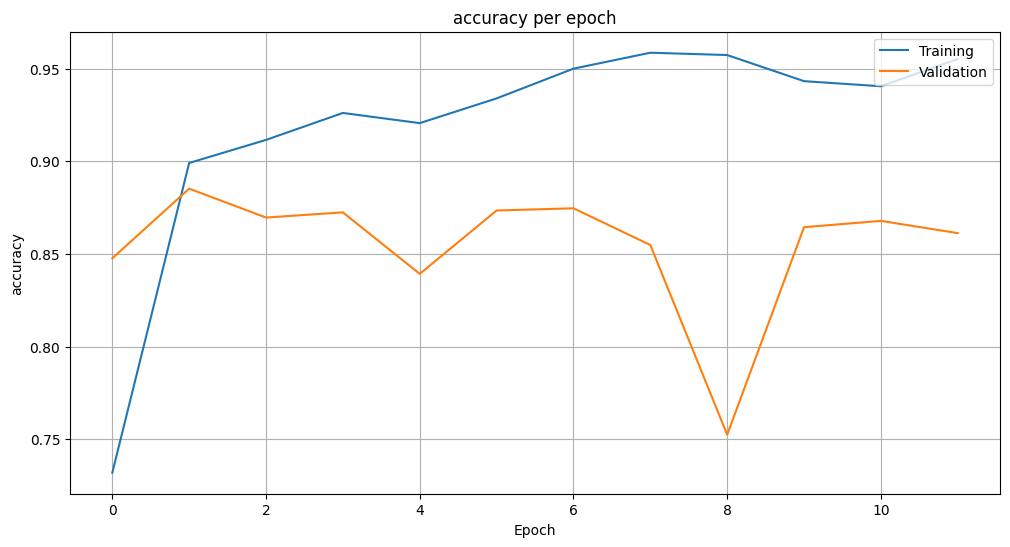

In [62]:
plt.figure(figsize=(12, 6))
plt.plot(history_LSTM_LE.history['accuracy'])
plt.plot(history_LSTM_LE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [63]:
LSTM_LE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 118s 151ms/step - accuracy: 0.8769 - loss: 0.3133


[0.3155806362628937, 0.8749200105667114]

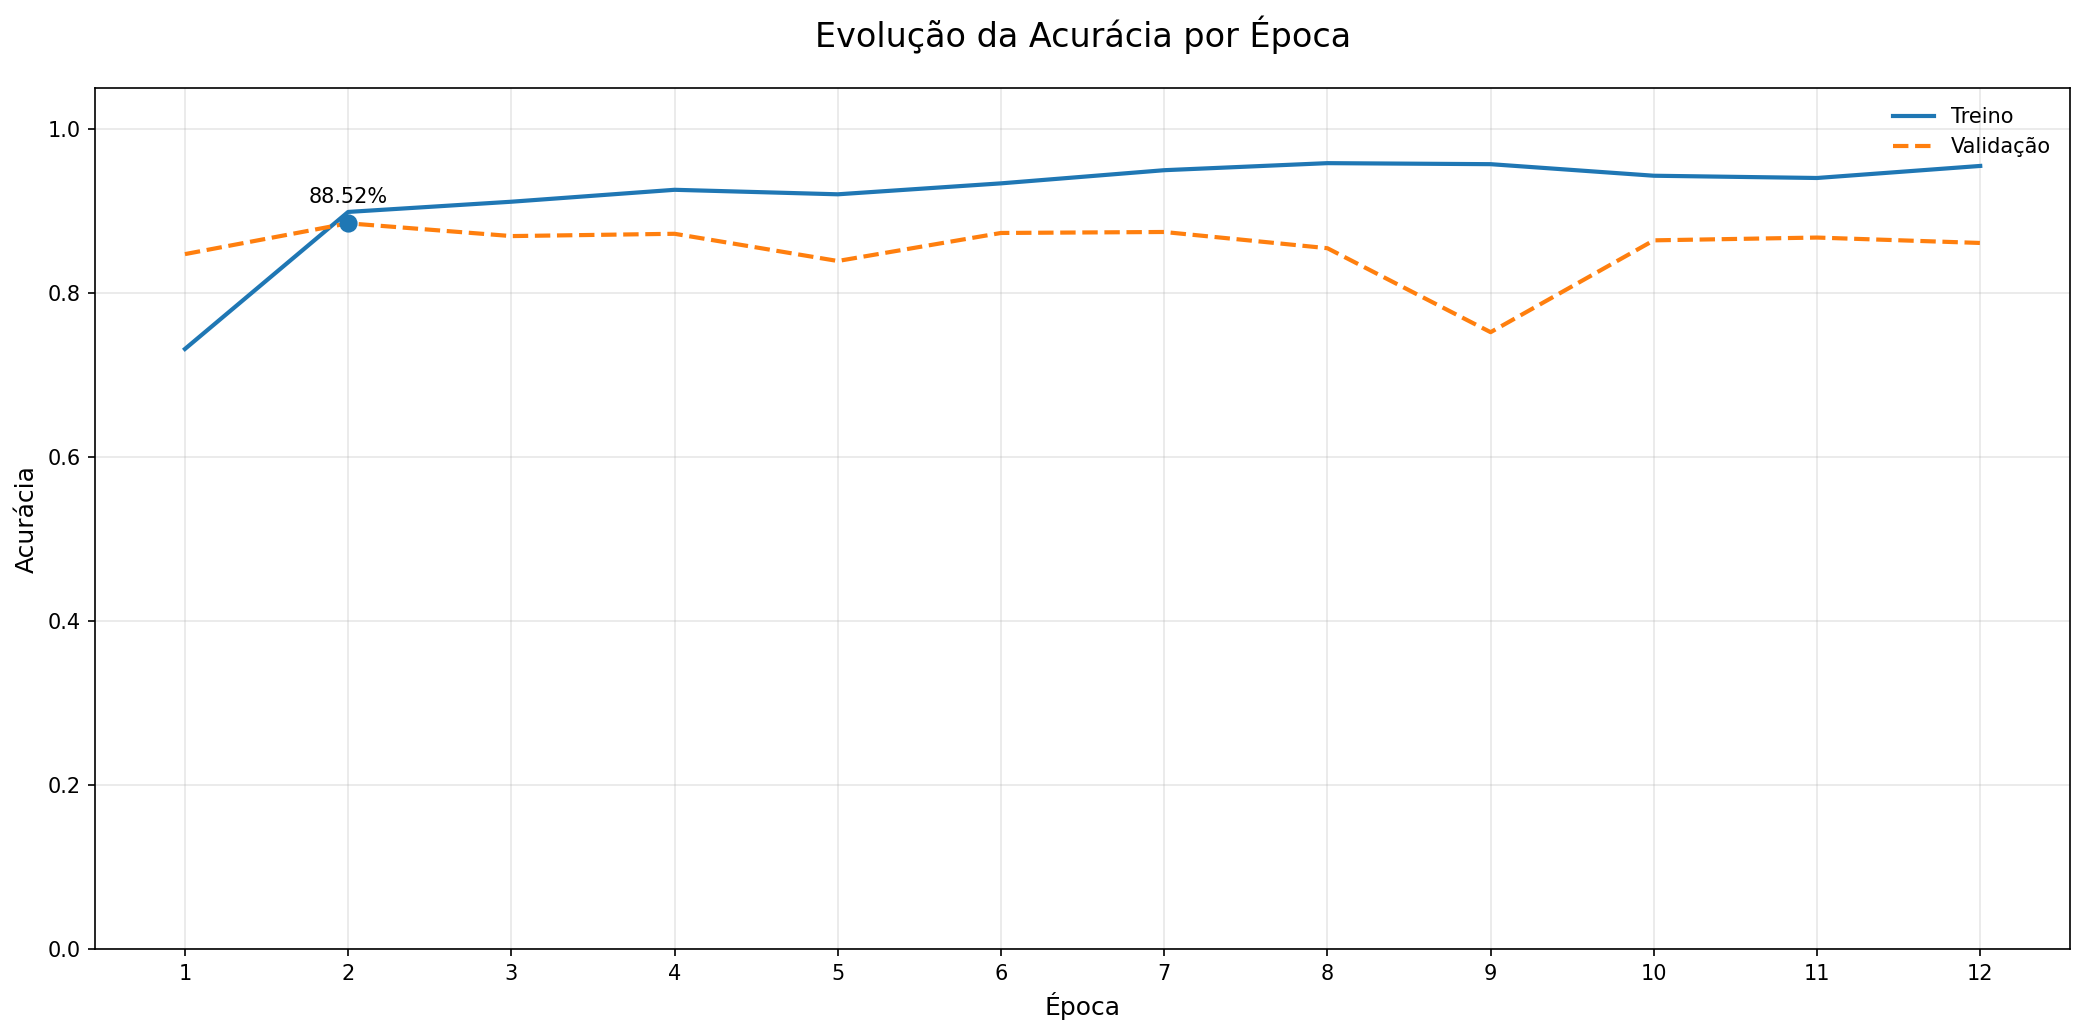

In [64]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_LSTM_LE.history['accuracy']
val_acc   = history_LSTM_LE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


# GRU

## HE

In [65]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [66]:
GRU_HE= Sequential()
GRU_HE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
GRU_HE.add(GRU(64, return_sequences=True,activation="relu", kernel_initializer=initializer_1))
GRU_HE.add(GRU(64, return_sequences=False,activation="relu", kernel_initializer=initializer_1))
GRU_HE.add(Dense(1, activation='sigmoid'))

GRU_HE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 500, 64)        │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,342,273 (5.12 MB)

 Trainable params: 1,342,273 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

Optimizer= Adam(learning_rate=0.001)

GRU_HE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [68]:
history_GRU_HE= GRU_HE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.5867 - loss: 0.6883 - val_accuracy: 0.7080 - val_loss: 0.5816
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 223s 3s/step - accuracy: 0.7722 - loss: 0.5165 - val_accuracy: 0.7382 - val_loss: 0.4990
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 219s 3s/step - accuracy: 0.8167 - loss: 0.4153 - val_accuracy: 0.8176 - val_loss: 0.4331
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.8776 - loss: 0.2935 - val_accuracy: 0.8612 - val_loss: 0.3498
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 235s 3s/step - accuracy: 0.9288 - loss: 0.1870 - val_accuracy: 0.8524 - val_loss: 0.3782
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.9474 - loss: 0.1463 - val_accuracy: 0.8682 - val_loss: 0.4160
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 211s 3s/step - accuracy: 0.9536 - loss: 0.1265 - val_accuracy: 0.8434 - val_loss: 0.4272
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - accuracy: 0.9450 - loss: 0.1390 - val_accuracy: 0.

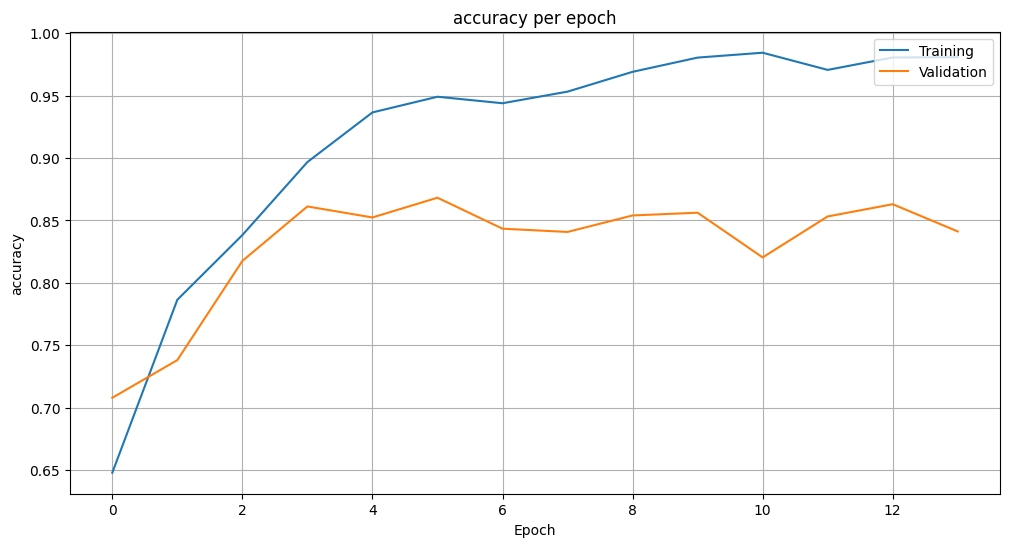

In [69]:
plt.figure(figsize=(12, 6))
plt.plot(history_GRU_HE.history['accuracy'])
plt.plot(history_GRU_HE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [70]:
GRU_HE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.8517 - loss: 0.3600


[0.3523954153060913, 0.8563200235366821]

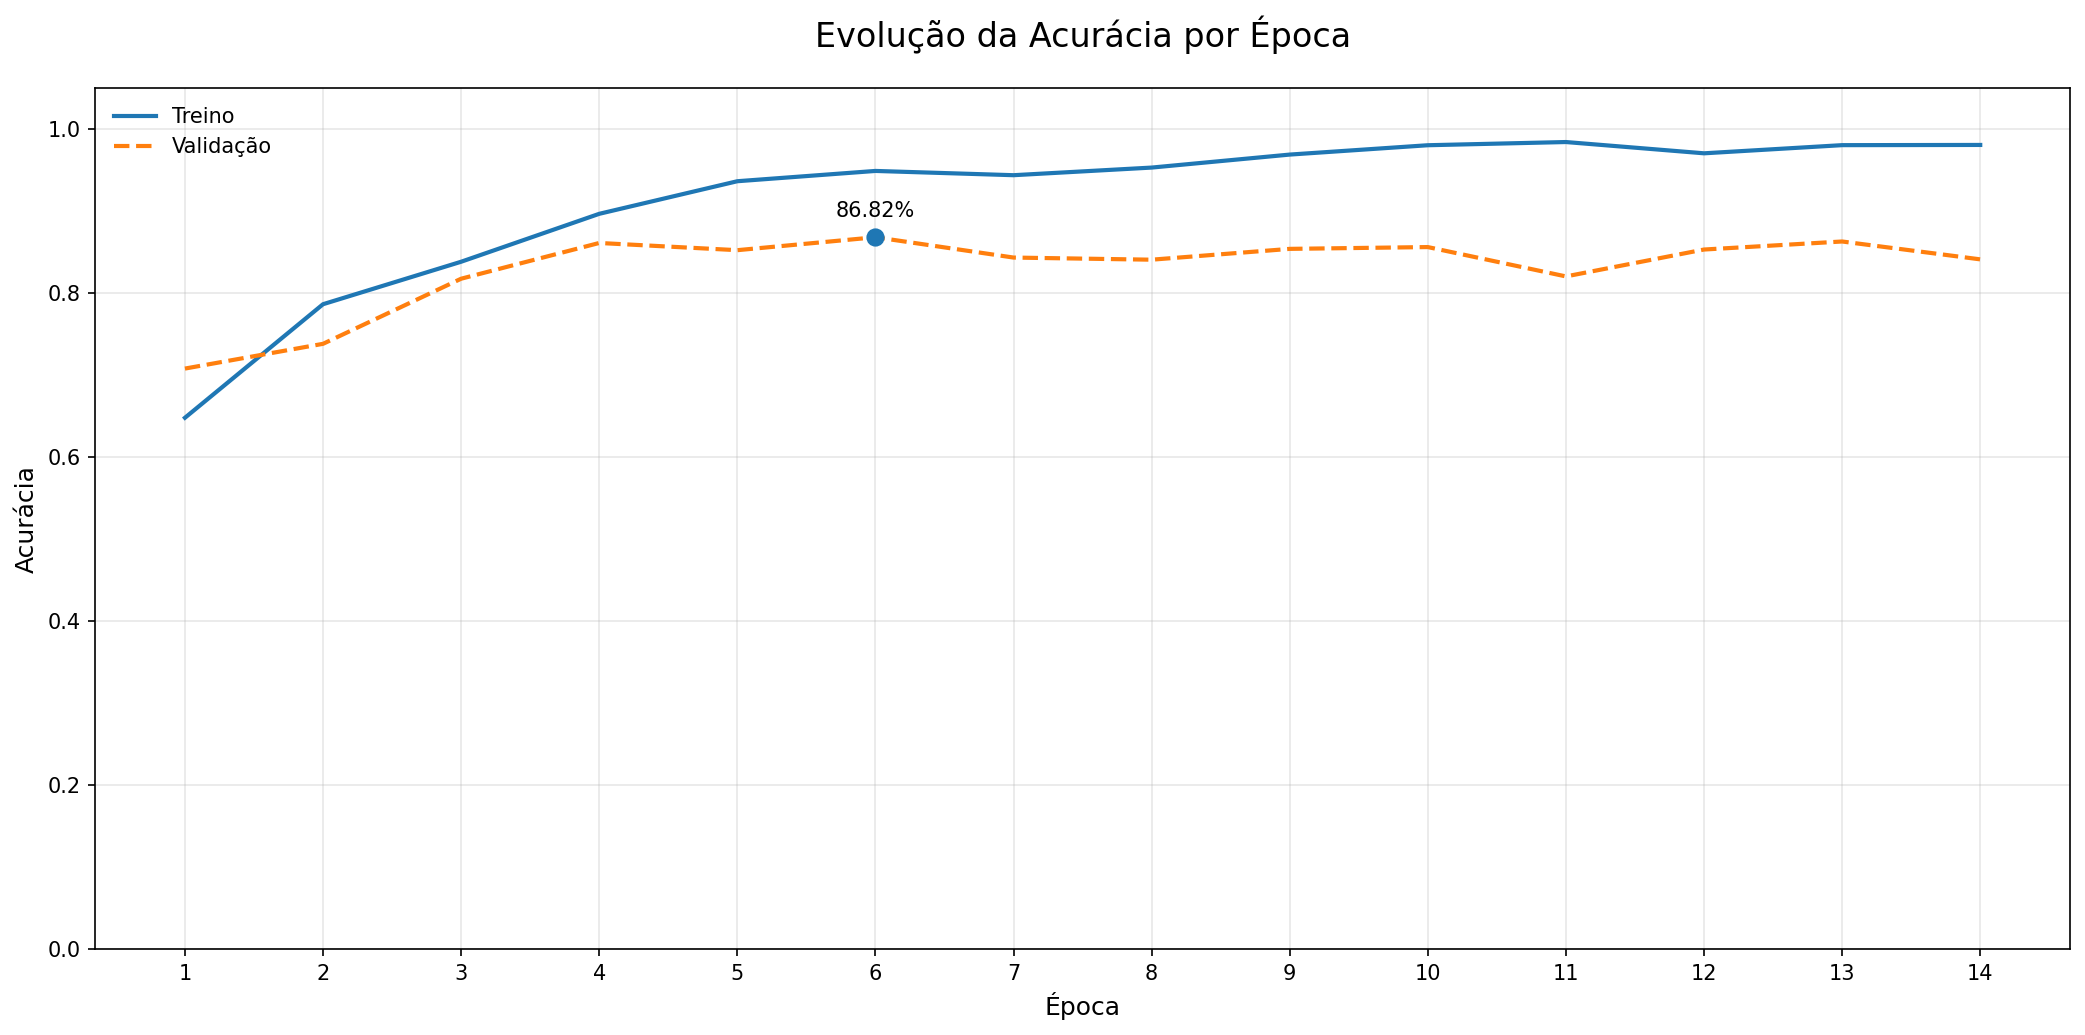

In [71]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_GRU_HE.history['accuracy']
val_acc   = history_GRU_HE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


## GLorot

In [72]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [73]:
GRU_GL= Sequential()
GRU_GL.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
GRU_GL.add(GRU(64, return_sequences=True,activation="tanh", kernel_initializer=initializer_2))
GRU_GL.add(GRU(64, return_sequences=False,activation="tanh", kernel_initializer=initializer_2))
GRU_GL.add(Dense(1, activation='sigmoid'))

GRU_GL.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 500, 64)        │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,342,273 (5.12 MB)

 Trainable params: 1,342,273 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

In [74]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

GRU_GL.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [75]:
history_GRU_GL= GRU_GL.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.6200 - loss: 0.6231 - val_accuracy: 0.8490 - val_loss: 0.3578
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.8791 - loss: 0.2936 - val_accuracy: 0.8650 - val_loss: 0.3308
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.9140 - loss: 0.2215 - val_accuracy: 0.8684 - val_loss: 0.3229
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.9153 - loss: 0.2187 - val_accuracy: 0.8486 - val_loss: 0.3504
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.9301 - loss: 0.1857 - val_accuracy: 0.8744 - val_loss: 0.3437
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.9533 - loss: 0.1311 - val_accuracy: 0.8608 - val_loss: 0.3759
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.9652 - loss: 0.1034 - val_accuracy: 0.7746 - val_loss: 0.5244
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.9236 - loss: 0.1894 - val_accuracy: 0.

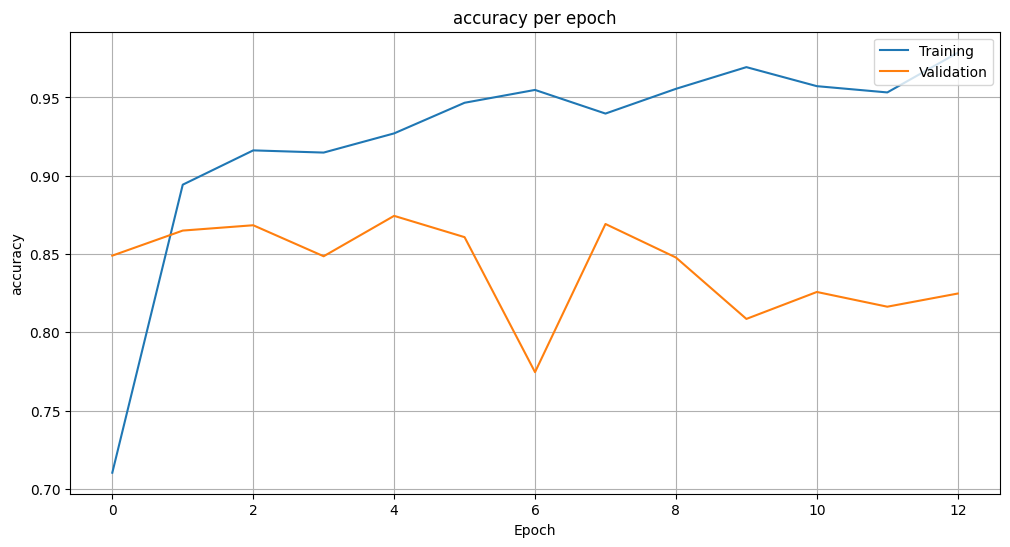

In [76]:
plt.figure(figsize=(12, 6))
plt.plot(history_GRU_GL.history['accuracy'])
plt.plot(history_GRU_GL.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [77]:
GRU_GL.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.8544 - loss: 0.3387


[0.3379513919353485, 0.8556399941444397]

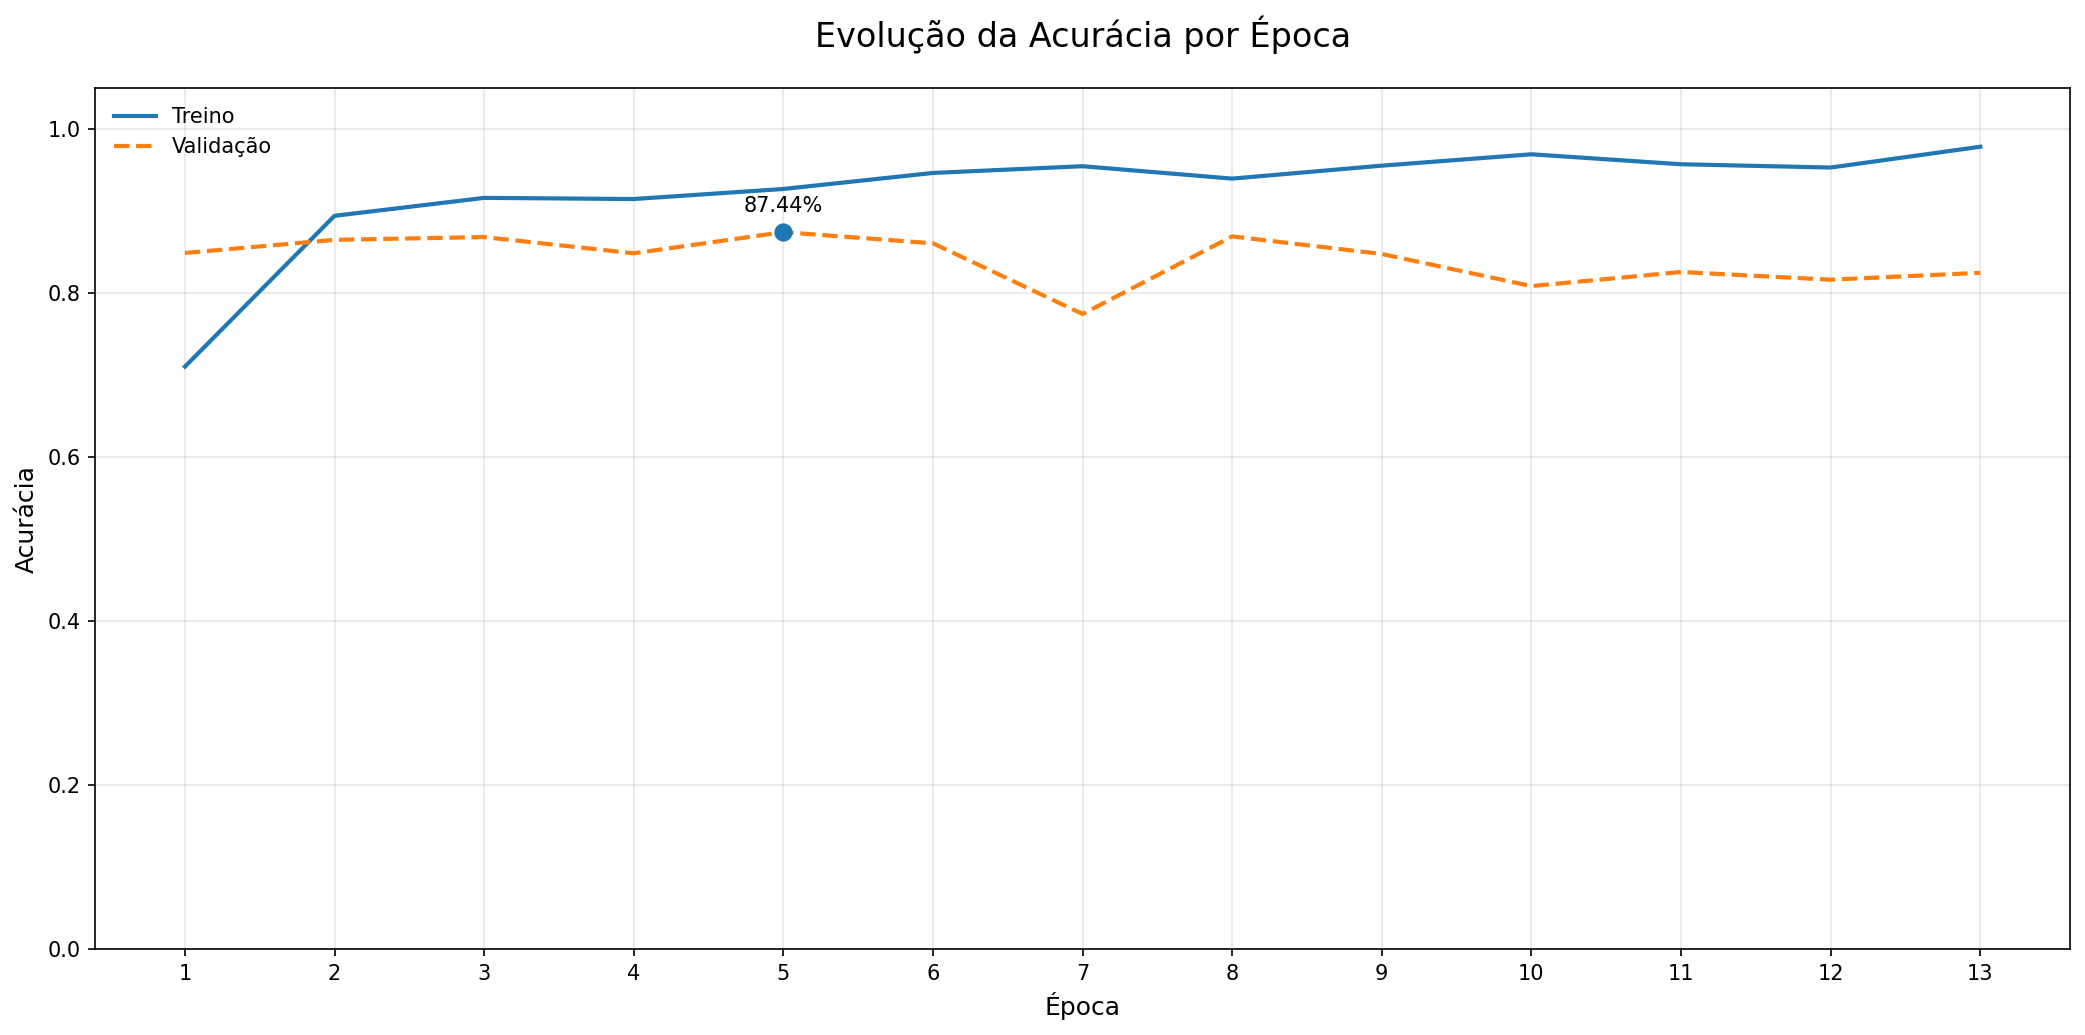

In [78]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_GRU_GL.history['accuracy']
val_acc   = history_GRU_GL.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


## LeCun

In [79]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [80]:
GRU_LE= Sequential()
GRU_LE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
GRU_LE.add(GRU(64, return_sequences=True,activation="tanh", kernel_initializer=initializer_3))
GRU_LE.add(GRU(64, return_sequences=False,activation="tanh", kernel_initializer=initializer_3))
GRU_LE.add(Dense(1, activation='sigmoid'))

GRU_LE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 500, 64)        │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,342,273 (5.12 MB)

 Trainable params: 1,342,273 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

In [81]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

GRU_LE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [82]:
history_GRU_LE= GRU_LE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.6194 - loss: 0.6220 - val_accuracy: 0.8446 - val_loss: 0.3643
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.8746 - loss: 0.3005 - val_accuracy: 0.8842 - val_loss: 0.3400
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.9208 - loss: 0.2152 - val_accuracy: 0.8522 - val_loss: 0.3537
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.9107 - loss: 0.2341 - val_accuracy: 0.8120 - val_loss: 0.4857
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.9143 - loss: 0.2175 - val_accuracy: 0.8370 - val_loss: 0.4259
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.9303 - loss: 0.1811 - val_accuracy: 0.7780 - val_loss: 0.5665
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.9358 - loss: 0.1674 - val_accuracy: 0.8188 - val_loss: 0.5464
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.9622 - loss: 0.1128 - val_accuracy: 0.

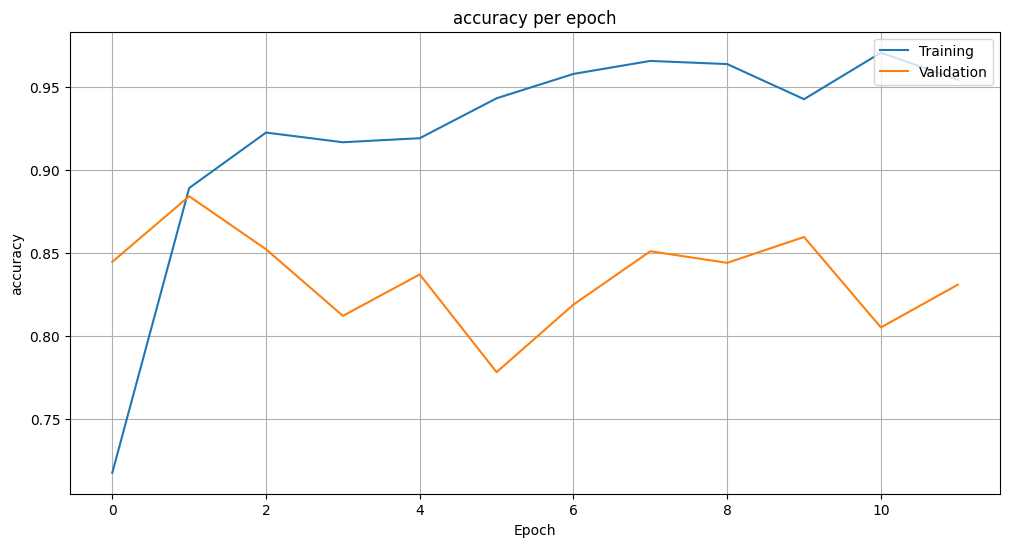

In [83]:
plt.figure(figsize=(12, 6))
plt.plot(history_GRU_LE.history['accuracy'])
plt.plot(history_GRU_LE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [84]:
GRU_LE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.8677 - loss: 0.3672


[0.3616862893104553, 0.8686800003051758]

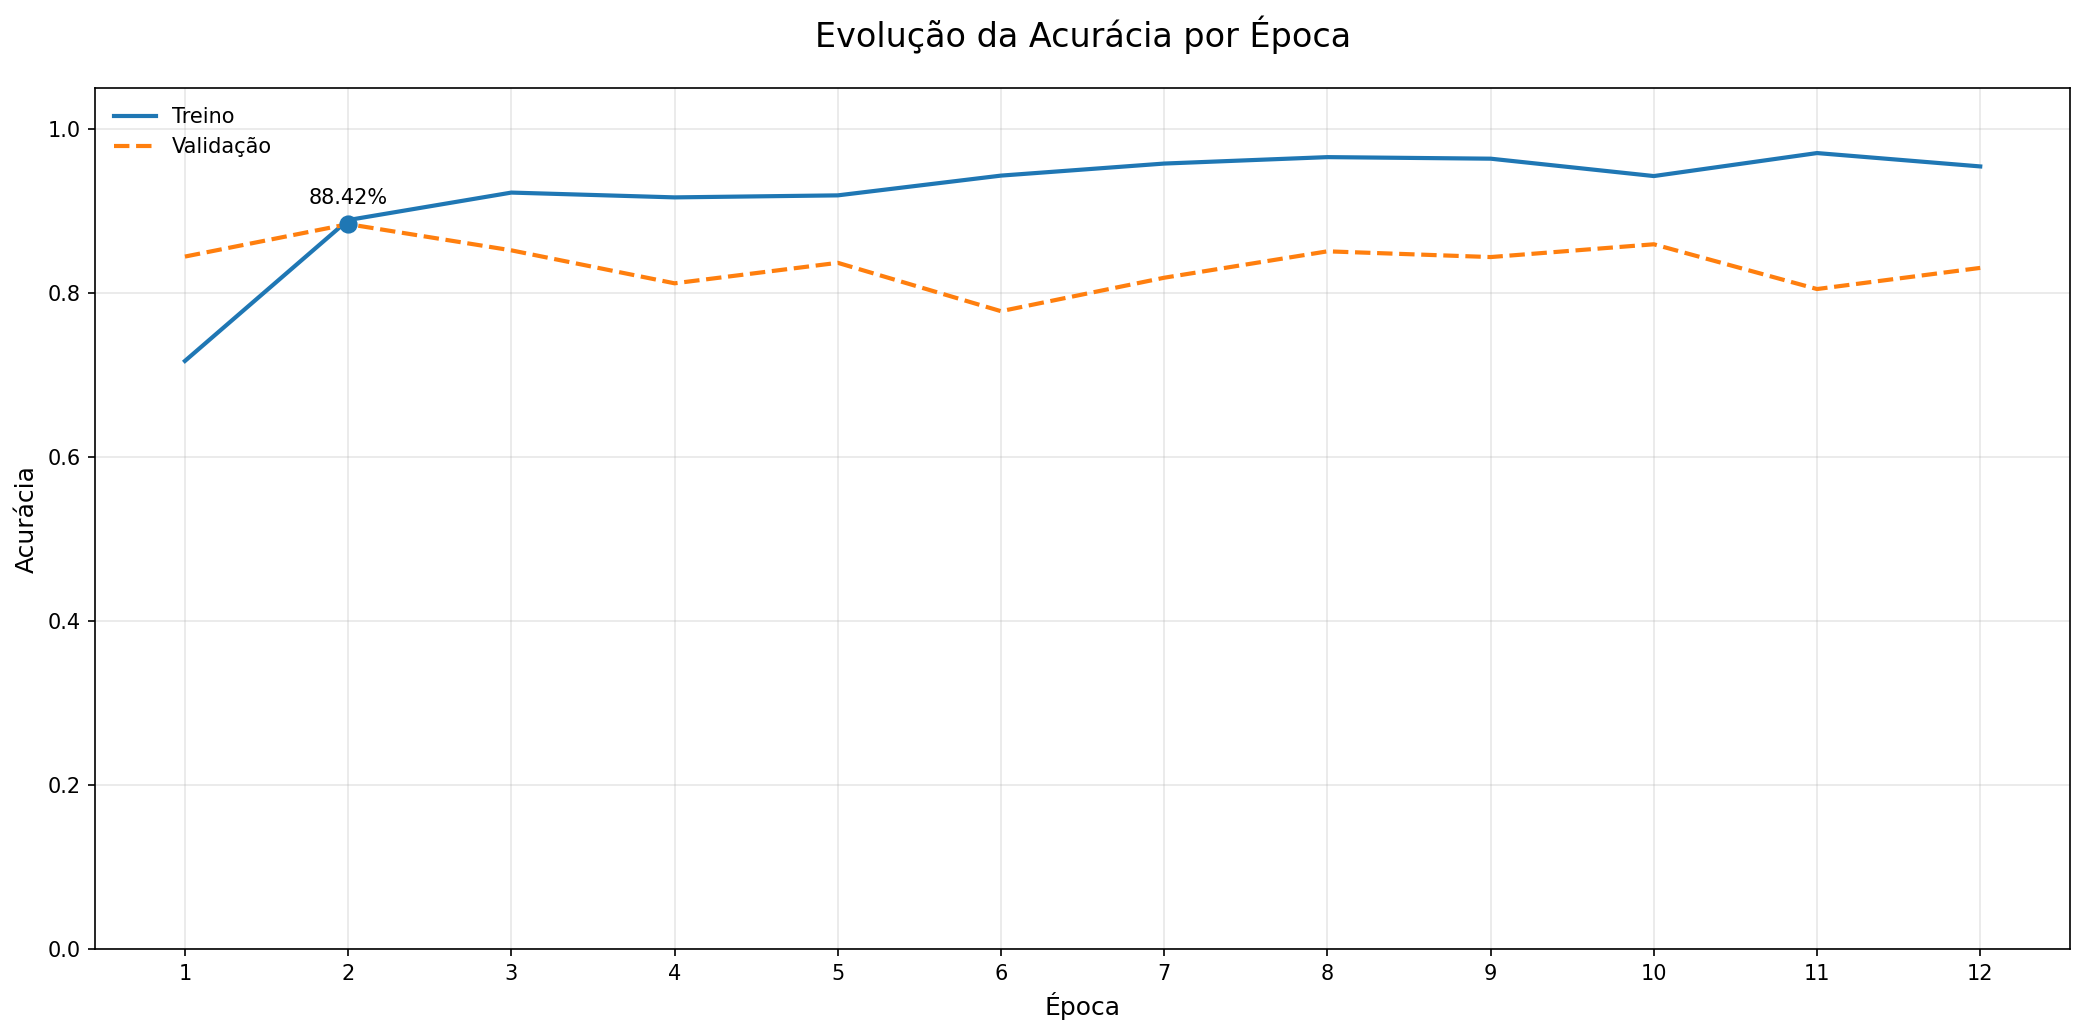

In [85]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_GRU_LE.history['accuracy']
val_acc   = history_GRU_LE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()
